# Tasks:

1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

2. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices.

3. Feature Engineering:
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

4. Decision Tree Classification:

Split the dataset into training and testing sets (e.g., using an 80-20 split).
Implement a Decision Tree Classification model using a library like scikit-learn.
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

5. Hyperparameter Tuning:

Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

6. Model Evaluation and Analysis:

Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
Visualize the decision tree structure to understand the rules learned by the model and identify important features

# Interview Questions:

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

2. What is the
 difference between the Label encoding and One-hot encoding?


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [ ]:
df = pd.read_excel('/content/heart_disease.xlsx')

In [ ]:
df

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...
5,restecg,"ecg observation at resting condition, -- Val..."
6,thalch,maximum heart rate achieved
7,exang,exercise induced angina
8,oldpeak,ST depression induced by exercise relative to ...
9,slope,the slope of the peak exercise ST segment


In [ ]:
df.head()

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [ ]:
df.shape

(12, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           12 non-null     object
 1   Age in years  12 non-null     object
dtypes: object(2)
memory usage: 324.0+ bytes


In [ ]:
df.describe(include='all')

,age,Age in years
count,12,12
unique,12,12
top,Gender,"Gender ; Male - 1, Female -0"
freq,1,1


In [ ]:
df.isnull().sum()

,0
age,0
Age in years,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
import pandas as pd

# Load the correct sheet, which is 'Heart_disease'
df = pd.read_excel('/content/heart_disease.xlsx', sheet_name='Heart_disease')

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display column names
print('DataFrame columns after loading the correct sheet:')
print(df.columns)

# Display the count of each heart disease class
print('\nValue counts for the "num" column:')
print(df['num'].value_counts().sort_index())

DataFrame columns after loading the correct sheet:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

Value counts for the "num" column:
num
0    399
1    265
2    109
3    107
4     28
Name: count, dtype: int64


**Interpretation**

class 0 has the largest number of observations, while class 4 has considerably fewer observations.
Therefore, the target variable is imbalanced. particularly for class 4.

This should be considered when evaluating the model. Accuracy alone may not provide a complete picture. score should always be connected.

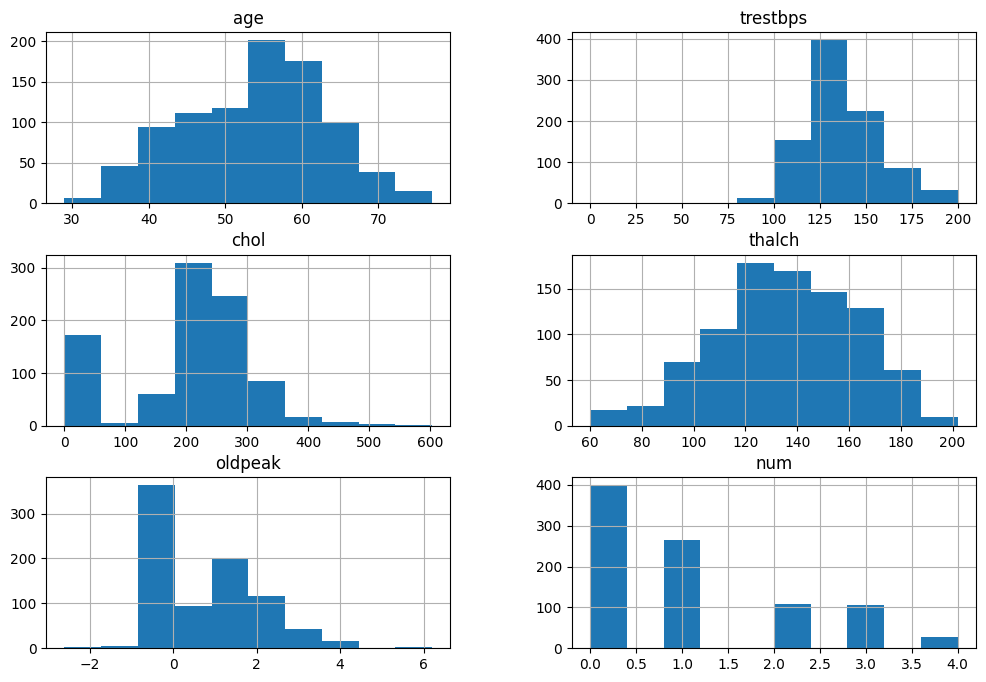

In [ ]:
# Histograms
df.hist(figsize=(12,8))
plt.show()

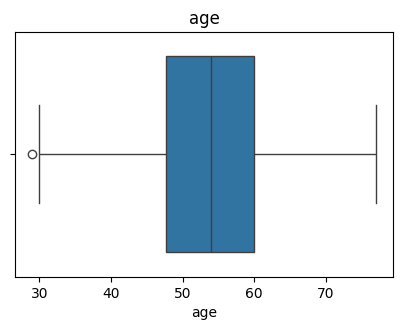

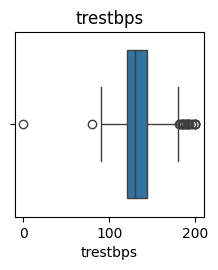

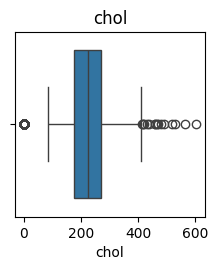

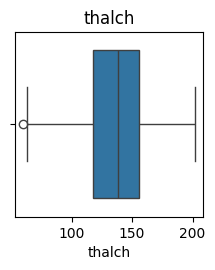

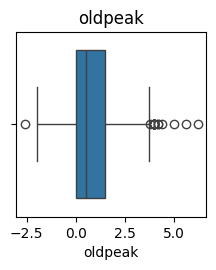

In [ ]:
# Box plots and Outlier Detection
numerical_columns = ["age", "trestbps", "chol", "thalch", "oldpeak"]
plt.figure(figsize=(12,6))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()
    plt.show()

# Interpretation

The box plots help identify potential outliers.
For example, some observations have unusally high or low variables such as cholesterol, resting blood pressure, or oldpeak.

However,medical measurements that appear as outliers should not automatically be deleted because they may represent genuine patient condition.

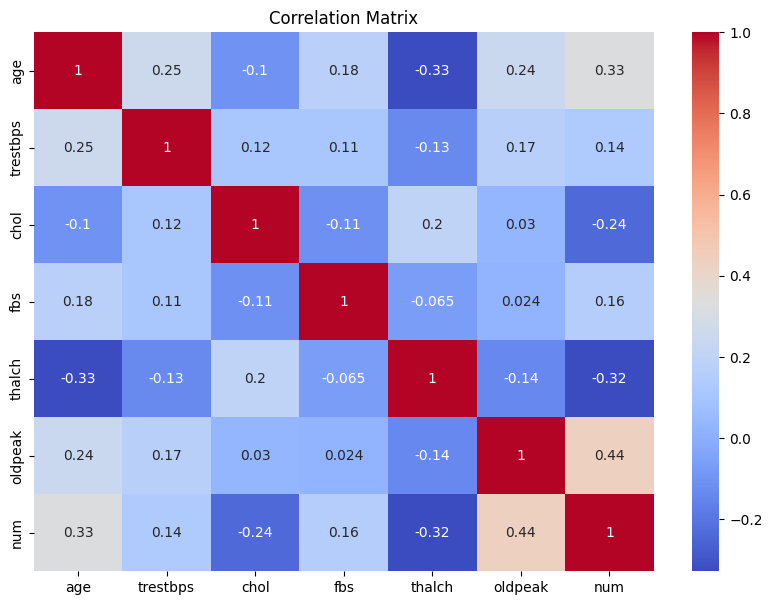

In [ ]:
# Correlation matrix
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),
            annot = True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Separating Feature and Target
X = df.drop("num",axis=1)
y=df["num"]

# Correcting mixed types and typos in 'exang' column
X['exang'] = X['exang'].apply(str)
X['exang'] = X['exang'].replace('TRUE', 'True')

In [ ]:
categorical_colums = ["sex","cp","restecg","exang","slope","thal"]

In [ ]:
categorical_colums = ["age","trestbps","chol","thalch","oldpeak"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
from sklearn import pipeline
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler # Import StandardScaler for numerical scaling
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_excel('/content/heart_disease.xlsx', sheet_name='Heart_disease')

df.columns = df.columns.str.strip()
df = df.drop_duplicates()
X = df.drop('num', axis=1)
y = df['num']

# Handle potential non-string 'exang' values before .astype(str) in case of NaN or other types
X['exang'] = X['exang'].fillna('').astype(str) # Fill NaN with empty string before converting to str
X['exang'] = X['exang'].replace('TRUE', 'True') # Correct typo as identified earlier
X['exang'] = X['exang'].replace('FALSE', 'False') # Also handle 'FALSE' if it exists

# Ensure 'fbs' is correctly handled if it's in categorical columns and not numeric
# Based on previous analysis, 'fbs' is a categorical column.

numerical_columns = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
categorical_colums = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42,
                                                    stratify=y)

# Define numerical pipeline with imputation and scaling
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler()) # Add a scaler for numerical features
])

# Define categorical pipeline with imputation and one-hot encoding
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("encoder", OneHotEncoder(handle_unknown = 'ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_columns),
        ('cat', categorical_pipeline, categorical_colums)
    ])

# Create the full pipeline including preprocessing and the classifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Fit the model
model_pipeline.fit(x_train, y_train)

# Predict and evaluate
y_pred = model_pipeline.predict(x_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.4065934065934066
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.62      0.66        80
           1       0.30      0.30      0.30        53
           2       0.12      0.14      0.12        22
           3       0.14      0.19      0.16        21
           4       0.33      0.17      0.22         6

    accuracy                           0.41       182
   macro avg       0.32      0.28      0.29       182
weighted avg       0.44      0.41      0.42       182



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__criterion': ["gini", "entropy", "log_loss"],
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 5, 10]
}

grid_search = GridSearchCV(
    model_pipeline, # Use model_pipeline from the previous cell
    param_grid,
    cv=5,
    scoring="f1_weighted", # Corrected spelling
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("best parameters:")
print(grid_search.best_params_)
print("best cross validation score:")
print(grid_search.best_score_)


best parameters:
{'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}
best cross validation score:
0.5181262575228213


In [ ]:
# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(x_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Accuracy of the tuned model on the test set:")
print(tuned_accuracy)

print("Decision Tree Classifier:")
print("--------------------------")
print("Accuracy:", tuned_accuracy)

print("\nClassification Report of the tuned model:")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix of the tuned model:")
print(confusion_matrix(y_test, y_pred_tuned))

Accuracy of the tuned model on the test set:
0.521978021978022
Decision Tree Classifier:
--------------------------
Accuracy: 0.521978021978022

Classification Report of the tuned model:
              precision    recall  f1-score   support

           0       0.75      0.69      0.72        80
           1       0.45      0.64      0.53        53
           2       0.17      0.23      0.20        22
           3       0.25      0.05      0.08        21
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.32      0.32      0.30       182
weighted avg       0.51      0.52      0.50       182


Confusion Matrix of the tuned model:
[[55 19  5  1  0]
 [ 9 34  9  1  0]
 [ 6 10  5  1  0]
 [ 3 10  7  1  0]
 [ 0  3  3  0  0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


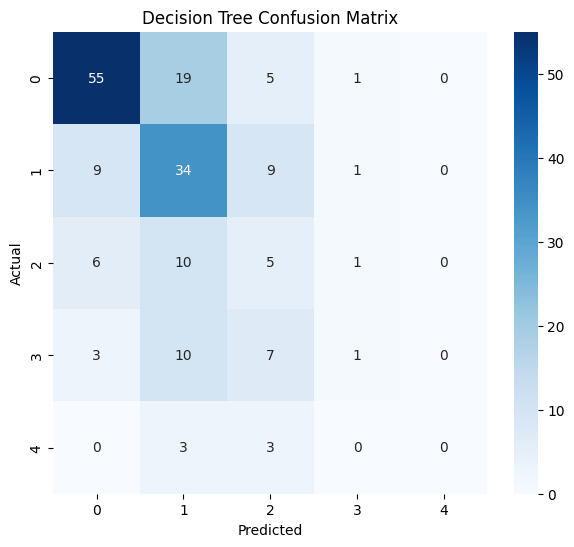

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns # Corrected: 'season' to 'seaborn'

cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(7,6))

sns.heatmap(cm, annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix') # Corrected: 'titel' to 'title'
plt.show()

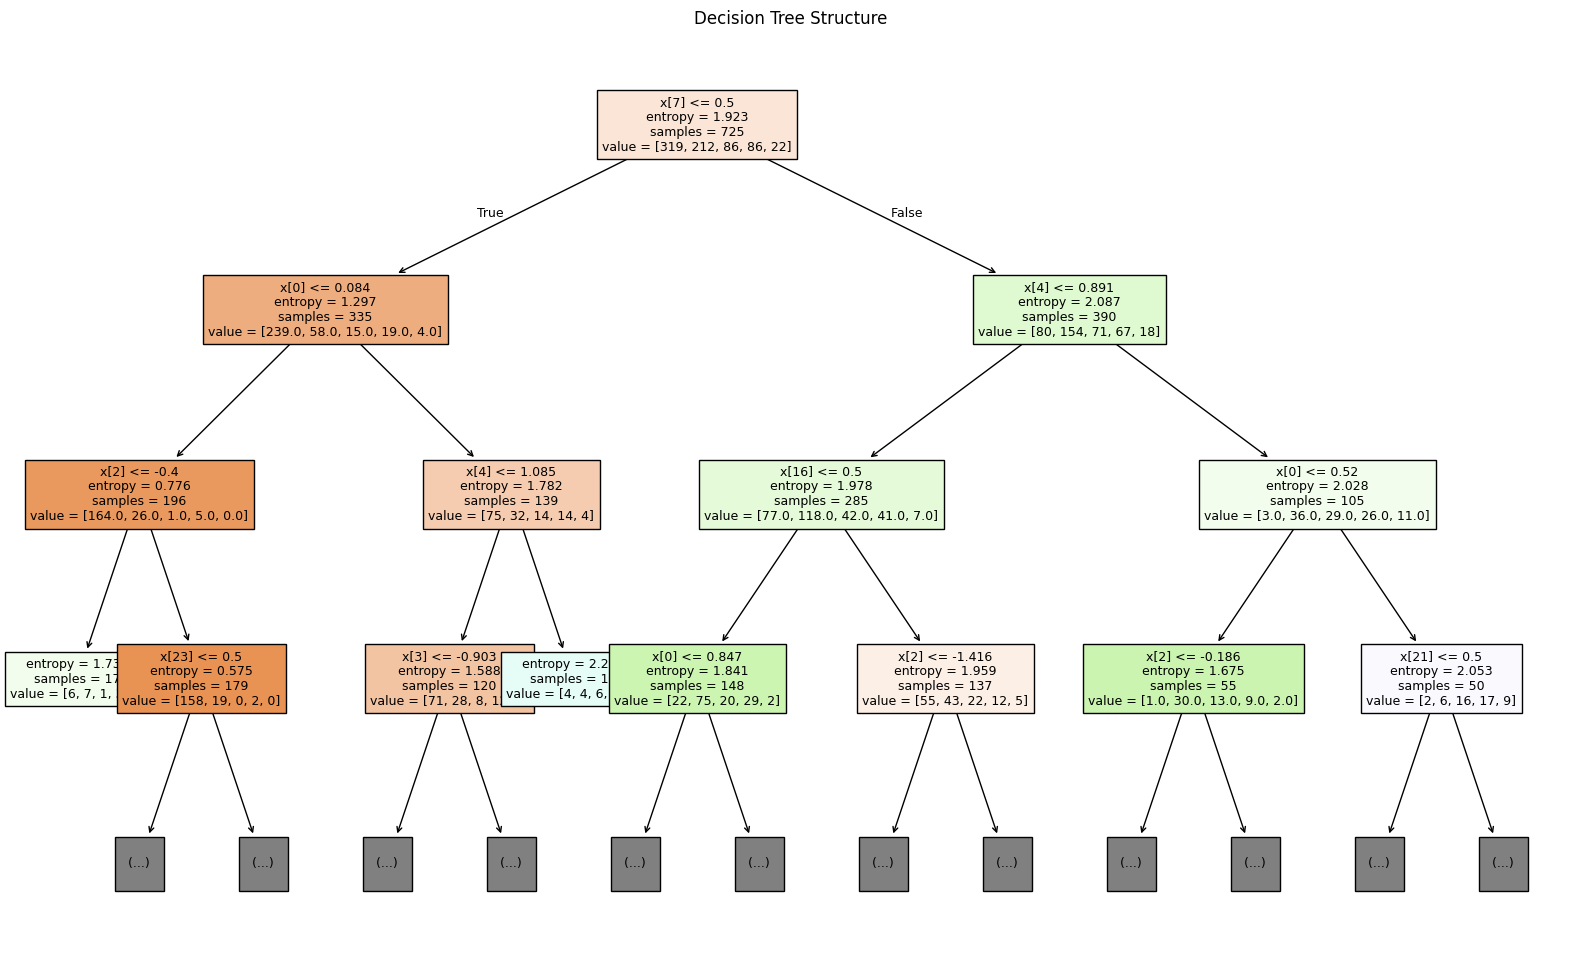

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_model = best_model.named_steps['classifier']
plt.figure(figsize=(20,12)) # Corrected: figsize should be a tuple parameter
plot_tree(tree_model, filled=True, max_depth=3,
          fontsize=9)
plt.title("Decision Tree Structure") # Corrected: 'Desion' to 'Decision'
plt.show()

In [ ]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out() # Corrected method name
importance = best_model.named_steps["classifier"].feature_importances_ # Corrected attribute name and access

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "Importance": importance
})
feature_importance = feature_importance.sort_values( # Corrected sorting syntax and assignment
    by="Importance", # Corrected column name to match DataFrame
    ascending=False # Corrected boolean literal
)
print("top10 importance feature:")
print(feature_importance.head(10))

top10 importance feature:
                    feature  Importance
7      cat__cp_asymptomatic    0.315839
0                  num__age    0.162900
2                 num__chol    0.142428
4              num__oldpeak    0.138151
3               num__thalch    0.062691
23         cat__thal_normal    0.051630
16         cat__exang_False    0.049638
21     cat__slope_upsloping    0.041710
1             num__trestbps    0.035013
8   cat__cp_atypical angina    0.000000


# Interview Questions:

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

2. What is the
difference between the Label encoding and One-hot encoding?


In [ ]:
1. Answer:
Decision Tree hyperparameters control the complexity of the tree. max_depth controls tree depth, min_samples_split and min_samples_leaf control splitting, and criterion determines how the best split is selected. Proper tuning helps reduce overfitting and improve performance.


In [ ]:
2.Answer:
Label Encoding assigns a numerical value to each category, while One-Hot Encoding creates separate binary columns for each category. Label Encoding is suitable for ordered categories, whereas One-Hot Encoding is usually better for categories without any natural order.